In [1]:
import os

import pandas as pd
import numpy as np
import typing
import matplotlib.pyplot as plt

import keras
from keras import layers
from keras import ops

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.nn.functional import mse_loss

2024-12-23 17:03:42.858225: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-23 17:03:42.879806: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734944622.898224 2658520 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734944622.903935 2658520 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-23 17:03:42.924489: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
route_distances = pd.read_csv("/staging/biology/u1307362/debby/datasets/PeMSD7_Full.zip/PeMSD7_W_228.csv", header=None).to_numpy()
speeds_array = pd.read_csv("/staging/biology/u1307362/debby/datasets/PeMSD7_Full.zip/PeMSD7_V_228.csv", header=None).to_numpy()

print(f"route_distances shape={route_distances.shape}")
print(f"speeds_array shape={speeds_array.shape}")

route_distances shape=(228, 228)
speeds_array shape=(12672, 228)


In [3]:
def preprocess(data_array: torch.Tensor, train_size: float, val_size: float):
    """Splits data into train/val/test sets and normalizes the data.

    Args:
        data_array: Tensor of shape `(num_time_steps, num_routes)`
        train_size: Proportion of the dataset to include in the train split.
        val_size: Proportion of the dataset to include in the validation split.

    Returns:
        `train_tensor`, `val_tensor`, `test_tensor`
    """
    num_time_steps = data_array.size(0)  
    num_train = int(num_time_steps * train_size)
    num_val = int(num_time_steps * val_size)

    # 切分數據
    train_tensor = data_array[:num_train]
    mean = train_tensor.mean(dim=0, keepdim=True)
    std = train_tensor.std(dim=0, keepdim=True)

    # 標準化數據
    train_tensor = (train_tensor - mean) / std
    val_tensor = (data_array[num_train : num_train + num_val] - mean) / std
    test_tensor = (data_array[num_train + num_val :] - mean) / std

    return train_tensor, val_tensor, test_tensor

# 轉換 speeds_array 成 PyTorch Tensor
speeds_tensor = torch.tensor(speeds_array, dtype=torch.float32)

# 使用 preprocess 函數
train_tensor, val_tensor, test_tensor = preprocess(speeds_tensor, train_size=0.7, val_size=0.2)

# 輸出結果
print(f"train set size: {train_tensor.shape}")
print(f"validation set size: {val_tensor.shape}")
print(f"test set size: {test_tensor.shape}")

torch.save(train_tensor, 'train_tensor.pt')
torch.save(val_tensor, 'val_tensor.pt')
torch.save(test_tensor, 'test_tensor.pt')

train set size: torch.Size([8870, 228])
validation set size: torch.Size([2534, 228])
test set size: torch.Size([1268, 228])


In [4]:
from torch.utils.data import Dataset, DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, data_array, input_sequence_length, forecast_horizon):
        self.data_array = data_array
        self.input_sequence_length = input_sequence_length
        self.forecast_horizon = forecast_horizon
        self.num_samples = data_array.size(0) - input_sequence_length - forecast_horizon + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        inputs = self.data_array[idx: idx + self.input_sequence_length]  # shape: (input_sequence_length, num_routes)
        targets = self.data_array[idx + self.input_sequence_length: idx + self.input_sequence_length + self.forecast_horizon]
        return inputs, targets


# 設定參數
batch_size = 64
input_sequence_length = 36
forecast_horizon = 12
multi_horizon = True

# 創建 Dataset 和 DataLoader
train_dataset = TimeSeriesDataset(train_tensor, input_sequence_length, forecast_horizon)
val_dataset = TimeSeriesDataset(val_tensor, input_sequence_length, forecast_horizon)
test_dataset = TimeSeriesDataset(test_tensor, input_sequence_length, forecast_horizon)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(val_dataset)}")
print(f"Number of test samples: {len(test_dataset)}")


for inputs, targets in train_loader:
    print(f"Batch input shape: {inputs.shape}")
    print(f"Batch target shape: {targets.shape}")
    break

Number of training samples: 8823
Number of validation samples: 2487
Number of test samples: 1221
Batch input shape: torch.Size([64, 36, 228])
Batch target shape: torch.Size([64, 12, 228])


In [5]:
def compute_adjacency_matrix(
    route_distances: np.ndarray, sigma2: float, epsilon: float
):
    """Computes the adjacency matrix from distances matrix.

    Args:
        route_distances: np.ndarray of shape `(num_routes, num_routes)`. Entry `i,j` of this array is the
            distance between roads `i,j`.
        sigma2: Determines the width of the Gaussian kernel applied to the square distances matrix.
        epsilon: A threshold specifying if there is an edge between two nodes. Specifically, `A[i,j]=1`
            if `np.exp(-w2[i,j] / sigma2) >= epsilon` and `A[i,j]=0` otherwise, where `A` is the adjacency
            matrix and `w2=route_distances * route_distances`

    Returns:
        A boolean graph adjacency matrix.
    """
    num_routes = route_distances.shape[0]
    route_distances = route_distances / 10000.0
    w2, w_mask = (
        route_distances * route_distances,
        np.ones([num_routes, num_routes]) - np.identity(num_routes),
    )
    return (np.exp(-w2 / sigma2) >= epsilon) * w_mask

In [6]:
class GraphInfo:
    def __init__(self, edges: typing.Tuple[list, list], num_nodes: int):
        self.edges = edges
        self.num_nodes = num_nodes


sigma2 = 0.1
epsilon = 0.5
adjacency_matrix = compute_adjacency_matrix(route_distances, sigma2, epsilon)
node_indices, neighbor_indices = np.where(adjacency_matrix == 1) #找出圖中的所有邊
graph = GraphInfo(
    edges=(node_indices.tolist(), neighbor_indices.tolist()),
    num_nodes=adjacency_matrix.shape[0],
)
print(f"number of nodes: {graph.num_nodes}, number of edges: {len(graph.edges[0])}")


number of nodes: 228, number of edges: 1664


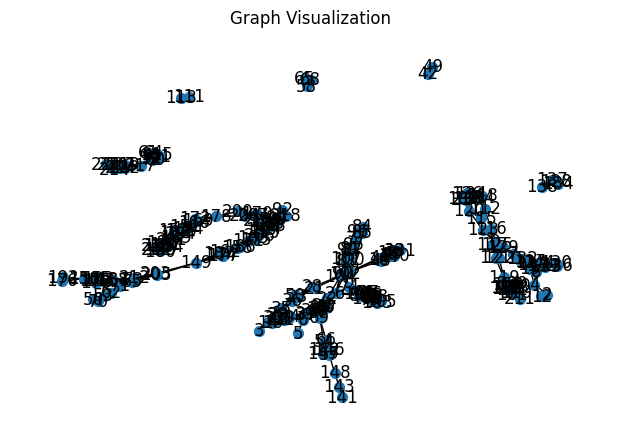

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()
G.add_edges_from(zip(graph.edges[0], graph.edges[1]))

plt.figure(figsize=(6, 4))
nx.draw(G, node_size=50, with_labels=True)
plt.title("Graph Visualization")
plt.show()

In [41]:
class GraphConv(nn.Module):
    def __init__(
        self,
        in_feat,
        out_feat,
        graph_info,
        aggregation_type="mean",
        combination_type="concat",
        activation=None,
    ):
        """
        Graph Convolutional Layer.
        Args:
            in_feat: Input feature dimension.
            out_feat: Output feature dimension.
            graph_info: Graph structure information (edges and number of nodes).
            aggregation_type: Type of aggregation for neighbor features ("mean" or "sum").
            combination_type: How to combine aggregated messages and node representations ("concat" or "add").
            activation: Activation function to apply (e.g., "relu", "tanh"). Default is None.
        """
        super(GraphConv, self).__init__()
        self.in_feat = in_feat
        self.out_feat = out_feat
        self.graph_info = graph_info
        self.aggregation_type = aggregation_type
        self.combination_type = combination_type
        self.weight = nn.Parameter(torch.empty(in_feat, out_feat))
        nn.init.xavier_uniform_(self.weight)
        self.activation = getattr(F, activation) if activation else None

    def aggregate(self, neighbour_representations, dst_nodes, num_nodes):
        """
        Aggregates neighbor representations.
        Args:
            neighbour_representations: Tensor of shape [num_edges, batch_size * seq_len, in_feat].
            dst_nodes: Tensor of shape [num_edges].
            num_nodes: Total number of nodes.
        Returns:
            Aggregated tensor of shape [num_nodes, batch_size * seq_len, in_feat].
        """
        aggregated = torch.zeros(
            (num_nodes, neighbour_representations.size(1), neighbour_representations.size(2)),
            device=neighbour_representations.device
        )
        aggregated.index_add_(0, dst_nodes, neighbour_representations)

        # Apply aggregation type
        if self.aggregation_type == "mean":
            degree = torch.bincount(dst_nodes, minlength=num_nodes).clamp(min=1).float().view(-1, 1, 1)
            aggregated = aggregated / degree
        elif self.aggregation_type != "sum":
            raise ValueError(f"Invalid aggregation type: {self.aggregation_type}")

        return aggregated

    def forward(self, features):
        assert features.shape[-1] == self.weight.shape[0], (
            f"Feature size ({features.shape[-1]}) does not match weight input size ({self.weight.shape[0]})"
        )
        src_nodes = torch.tensor(self.graph_info.edges[1], dtype=torch.long, device=features.device)
        dst_nodes = torch.tensor(self.graph_info.edges[0], dtype=torch.long, device=features.device)

        neighbour_representations = features[src_nodes]
        aggregated_messages = self.aggregate(neighbour_representations, dst_nodes, features.size(0))

        node_representations = torch.matmul(features, self.weight)

        if self.combination_type == "concat":
            h = torch.cat([node_representations, aggregated_messages], dim=-1)
        elif self.combination_type == "add":
            h = node_representations + aggregated_messages
        else:
            raise ValueError(f"Invalid combination type: {self.combination_type}")

        return h

In [42]:
class LSTMGC(nn.Module):
    def __init__(self, in_feat, out_feat, lstm_units, graph_info, combination_type="concat"):
        super(LSTMGC, self).__init__()
        self.graph_conv = GraphConv(in_feat, out_feat, graph_info, combination_type=combination_type)
        
        # Determine LSTM input size
        lstm_input_size = out_feat
        if combination_type == "concat":
            lstm_input_size += in_feat  # Add original feature size if concatenating

        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=lstm_units, batch_first=True)

    def forward(self, inputs):
        batch_size, seq_len, num_nodes, in_feat = inputs.shape

        inputs = inputs.permute(2, 0, 1, 3)  # (num_nodes, batch_size, seq_len, in_feat)
        inputs = inputs.reshape(num_nodes, batch_size * seq_len, in_feat)  # (num_nodes, batch_size * seq_len, in_feat)

        gcn_out = self.graph_conv(inputs)

        gcn_out = gcn_out.view(num_nodes, batch_size, seq_len, -1)
        gcn_out = gcn_out.permute(1, 2, 0, 3)

        gcn_out = gcn_out.reshape(batch_size * num_nodes, seq_len, -1)
        lstm_out, _ = self.lstm(gcn_out)
        lstm_out = lstm_out.view(batch_size, num_nodes, seq_len, -1).permute(0, 2, 1, 3)

        return lstm_out

In [43]:
class StackedLSTMGC(nn.Module):
    def __init__(self, in_feat, out_feat, lstm_units, input_seq_len, forecast_horizon, graph_info):
        super(StackedLSTMGC, self).__init__()
        self.lstm_gc1 = LSTMGC(in_feat, out_feat, lstm_units, graph_info)
        self.lstm_gc2 = LSTMGC(lstm_units, out_feat, lstm_units, graph_info)  # Adjusted in_feat to lstm_units
        self.dense = nn.Sequential(
            nn.Linear(lstm_units, lstm_units // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(lstm_units // 2, forecast_horizon)
        )

    def forward(self, inputs):

        output1 = self.lstm_gc1(inputs)

        output2 = self.lstm_gc2(output1)  # Adjusted input to match lstm_gc2

        output2 = output2[:, -1, :, :]

        dense_out = self.dense(output2)

        dense_out = dense_out.permute(0, 2, 1)

        return dense_out


In [44]:
# Model Hyperparameters
in_feat = 1
out_feat = 12
lstm_units = 64
input_sequence_length = 36
forecast_horizon = 12
batch_size = 128
epochs = 100

# Graph Info
graph_info = GraphInfo(edges=(node_indices.tolist(), neighbor_indices.tolist()), num_nodes=route_distances.shape[0])

# Model Initialization
model = StackedLSTMGC(
    in_feat, out_feat, lstm_units, input_sequence_length, forecast_horizon, graph_info
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
loss_fn = nn.MSELoss()
best_val_loss = float('inf')

# Training Loop with Validation
for epoch in range(epochs):
    # ---- Training Phase ----
    model.train()
    total_loss = 0.0
    for inputs, targets in train_loader:
        # Move inputs and targets to the appropriate device
        inputs, targets = inputs.to(device), targets.to(device)

        # Ensure inputs have the correct shape by adding feature dimension
        if inputs.dim() == 3:  # Check if feature dimension is missing
            inputs = inputs.unsqueeze(-1)  # (batch_size, seq_len, num_nodes, in_feat)

        # Forward pass
        outputs = model(inputs)  # (batch_size, forecast_horizon, num_nodes)
        loss = loss_fn(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    # ---- Validation Phase ----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for val_inputs, val_targets in val_loader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)

            # Add feature dimension for validation inputs if missing
            if val_inputs.dim() == 3:
                val_inputs = val_inputs.unsqueeze(-1)

            val_outputs = model(val_inputs)
            loss = loss_fn(val_outputs, val_targets)
            val_loss += loss.item()

    # ---- Epoch Results ----
    avg_train_loss = total_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    # Save the best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best model saved at epoch {epoch+1}")


Epoch [1/100], Train Loss: 0.8771, Val Loss: 0.9300
Best model saved at epoch 1
Epoch [2/100], Train Loss: 0.8511, Val Loss: 0.9228
Best model saved at epoch 2
Epoch [3/100], Train Loss: 0.8444, Val Loss: 0.9124
Best model saved at epoch 3
Epoch [4/100], Train Loss: 0.8384, Val Loss: 0.9181
Epoch [5/100], Train Loss: 0.8325, Val Loss: 0.9006
Best model saved at epoch 5
Epoch [6/100], Train Loss: 0.8253, Val Loss: 0.8796
Best model saved at epoch 6
Epoch [7/100], Train Loss: 0.8105, Val Loss: 0.8572
Best model saved at epoch 7
Epoch [8/100], Train Loss: 0.7955, Val Loss: 0.8499
Best model saved at epoch 8
Epoch [9/100], Train Loss: 0.7858, Val Loss: 0.8460
Best model saved at epoch 9
Epoch [10/100], Train Loss: 0.7786, Val Loss: 0.8450
Best model saved at epoch 10
Epoch [11/100], Train Loss: 0.7692, Val Loss: 0.8346
Best model saved at epoch 11
Epoch [12/100], Train Loss: 0.7578, Val Loss: 0.8237
Best model saved at epoch 12
Epoch [13/100], Train Loss: 0.7467, Val Loss: 0.8226
Best mode

(1221, 12, 228)
(1221, 12, 228)
Model MSE: 0.5015


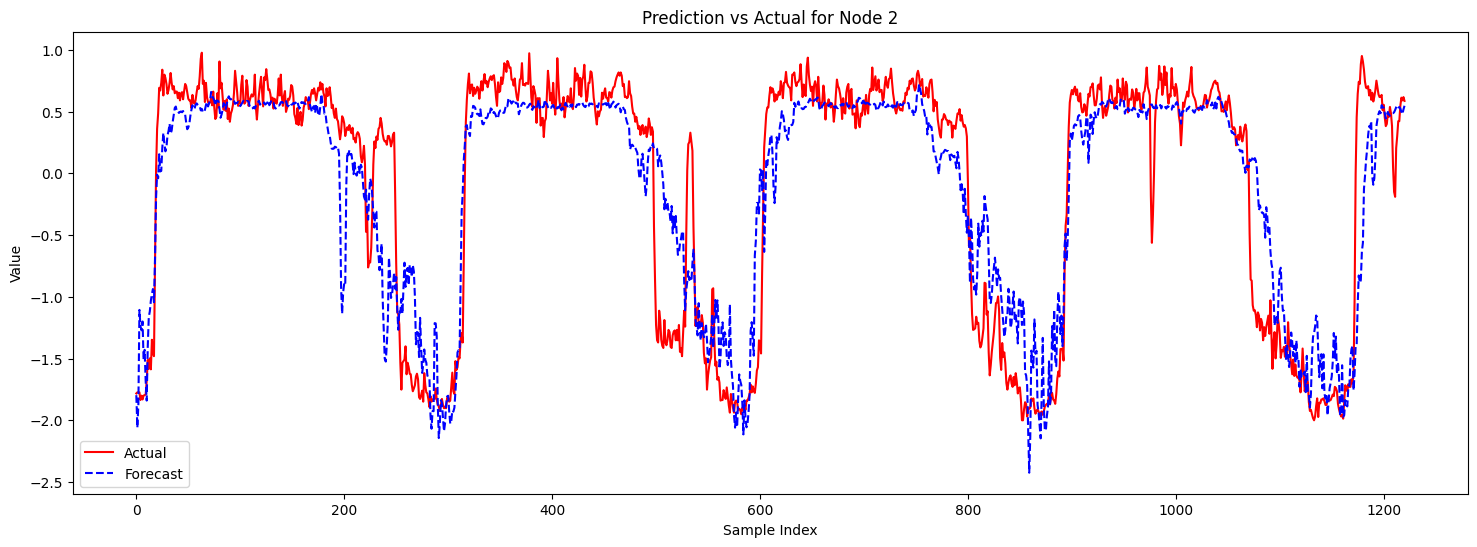

In [45]:
# 設置模型為評估模式
model.eval()

# 初始化變數來儲存預測和真實值
all_y = []
all_y_pred = []

# 遍歷所有測試批次
with torch.no_grad():
    for x_test, y in test_loader:
        x_test, y = x_test.to(device), y.to(device)
        
        # 預測輸出
        y_pred = model(x_test.unsqueeze(-1))  # Add in_feat dimension
        
        # 收集所有批次的真實值和預測值
        all_y.append(y.cpu().numpy())
        all_y_pred.append(y_pred.cpu().numpy())

# 將所有批次的預測值和真實值拼接起來
all_y = np.concatenate(all_y, axis=0)  # Shape: (1221, output_seq_len, num_nodes)
all_y_pred = np.concatenate(all_y_pred, axis=0)
print(all_y.shape)
print(all_y_pred.shape)

# 計算整體 MSE
model_mse = np.square(all_y_pred[:, :, :] - all_y[:, :, :]).mean()
print(f"Model MSE: {model_mse:.4f}")

# 繪圖：比較實際值與預測值
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.show()


all_y shape: (1221, 12, 228)
all_y_pred shape: (1221, 12, 228)
Model MSE (Original Scale): 71.2997
Model RMSE (Original Scale): 8.4439
Model MAE (Original Scale): 5.1728


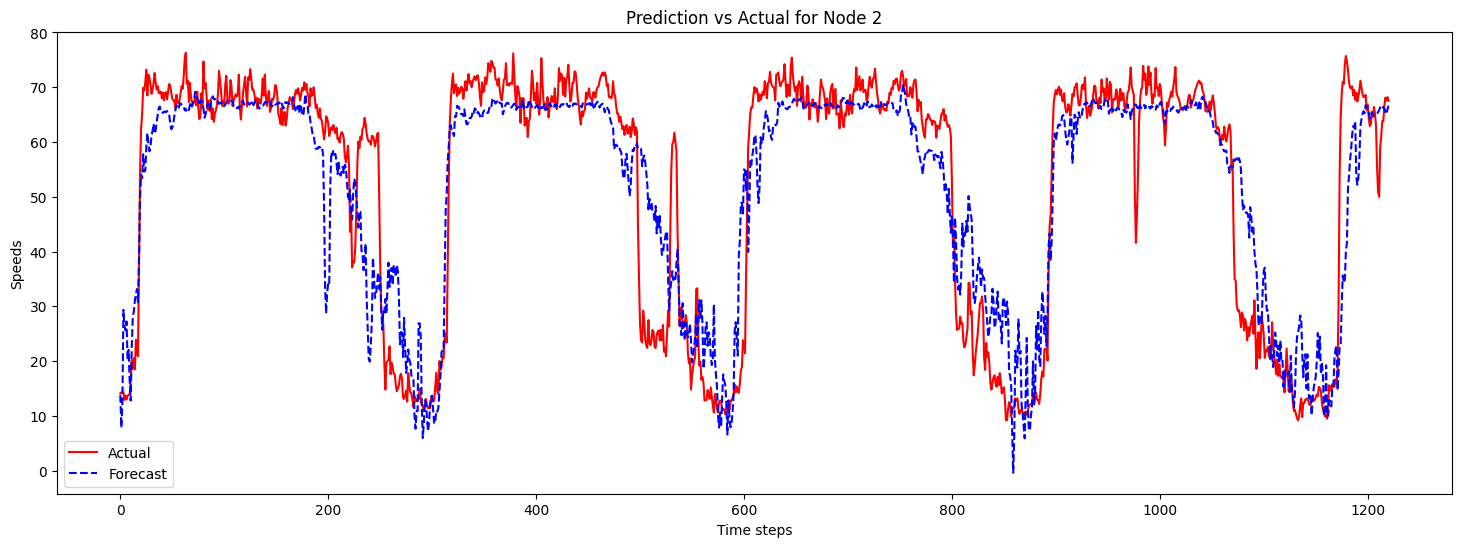

In [46]:
# 計算 train_tensor 的 mean 和 std
num_time_steps = speeds_tensor.size(0)
num_train = int(num_time_steps * 0.7)

train_tensor_orig = speeds_tensor[:num_train]
mean = train_tensor_orig.mean(dim=0, keepdim=True)
std = train_tensor_orig.std(dim=0, keepdim=True)

mean = mean.squeeze(0)  # Shape: (num_nodes,)
std = std.squeeze(0)    # Shape: (num_nodes,)

# 轉換為 NumPy 格式
mean_np = mean.cpu().numpy()  # (num_nodes,)
std_np = std.cpu().numpy()

mean_np = mean_np.reshape(1, 1, -1)  # Shape: (1, 1, num_nodes)
std_np = std_np.reshape(1, 1, -1)    # Shape: (1, 1, num_nodes)


# 檢查形狀
print("all_y shape:", all_y.shape)  # (1221, output_seq_len, num_nodes)
print("all_y_pred shape:", all_y_pred.shape)

# 反標準化到原始尺度
all_y_orig = all_y * std_np + mean_np            # Shape: (1221, output_seq_len, num_nodes)
all_y_pred_orig = all_y_pred * std_np + mean_np  # Shape: (1221, output_seq_len, num_nodes)

# 計算 MSE（Mean Square Error）
mse = np.square(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()
rmse = np.sqrt(mse)  
mae = np.abs(all_y_pred_orig[:, :, :] - all_y_orig[:, :, :]).mean()  

# 輸出結果
print(f"Model MSE (Original Scale): {mse:.4f}")
print(f"Model RMSE (Original Scale): {rmse:.4f}")
print(f"Model MAE (Original Scale): {mae:.4f}")

# 繪圖：比較實際值與預測值（原始尺度）
node_index = 1
plt.figure(figsize=(18, 6))
plt.plot(all_y_orig[:, 0, node_index], label="Actual", linestyle='-', color='r')     # 第一個時間步的實際值
plt.plot(all_y_pred_orig[:, 0, node_index], label="Forecast", linestyle='--', color='b')  # 第一個時間步的預測值
plt.legend()
plt.title(f"Prediction vs Actual for Node {node_index+1}")
plt.xlabel("Time steps")
plt.ylabel("Speeds")
plt.show()